In [1]:
import numpy as np
import matplotlib.pyplot as plt
import harmonica as hm
import verde as vd
import numpy as np
import time

import magali as mg


In [2]:
SEED = 5
rng = np.random.default_rng(SEED)
region = [30, 70, 30, 70]

In [3]:

def simple_model(region, spacing, rng):
    sensor_sample_distance = 5

    dipole_coordinates = (50, 50, -5)
    dipole_moments = hm.magnetic_angles_to_vec(1e-13, 30, 40)

    data = mg.dipole_bz_grid(
        region, spacing, sensor_sample_distance, dipole_coordinates, dipole_moments
    )

    noise = 10
    data += rng.normal(0, noise, data.shape)

    return data, dipole_coordinates, dipole_moments


def one_interf_model(region, spacing, rng):
    sensor_sample_distance = 5

    dipole_coordinates = (
        np.concatenate([[50], [40]]),  # x
        np.concatenate([[50], [40]]),  # y
        np.concatenate([[-5], [-10]]),  # z
    )
    dipole_moments = hm.magnetic_angles_to_vec(
        inclination=np.concatenate([[30], [-30]]),
        declination=np.concatenate([[40], [40]]),
        intensity=np.concatenate([[10e-14], [10e-14]]),  # A·m²
    )

    data = mg.dipole_bz_grid(
        region, spacing, sensor_sample_distance, dipole_coordinates, dipole_moments
    )

    noise = 10
    data += rng.normal(0, noise, data.shape)

    return data, dipole_coordinates, dipole_moments

/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


[49.99387179 49.99382618 -4.4035528 ]
-109.1385005419071
225
(np.float64(5.566703992264194e-14), np.float64(6.634139481689385e-14), np.float64(-4.9999999999999995e-14))


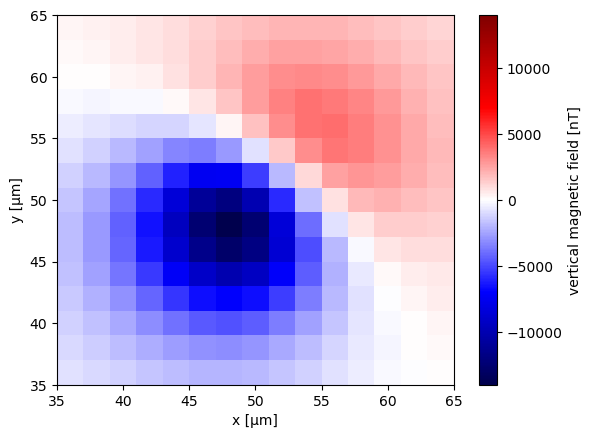

In [4]:
spacing = 2
data, dipole_coordinates, dipole_moments = simple_model(region, spacing, rng)
dx, dy, dz, tga = mg.gradient(data)

dataset = data.to_dataset()
dataset["dx"] = dx
dataset["dy"] = dy
dataset["dz"] = dz

dataset = dataset.sel(x=slice(35, 65), y=slice(35, 65))
dataset.bz.plot.pcolormesh(cmap="seismic")
table = vd.grid_to_table(dataset)

euler = hm.EulerDeconvolution(3)
euler.fit((table.x, table.y, table.z), (table.bz, table.dx, table.dy, table.dz))

print(euler.location_)
print(euler.base_level_)
print(table.bz.size)

print(dipole_moments)

/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


[49.98123609 49.97428731 -4.69623757]
-99.55788855770048
961


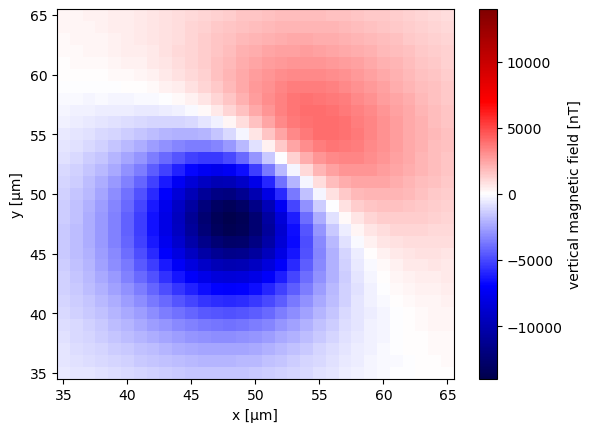

In [5]:
spacing = 1
data, dipole_coordinates, dipole_moments = simple_model(region, spacing, rng)
dx, dy, dz, tga = mg.gradient(data)

dataset = data.to_dataset()
dataset["dx"] = dx
dataset["dy"] = dy
dataset["dz"] = dz

dataset = dataset.sel(x=slice(35, 65), y=slice(35, 65))
dataset.bz.plot.pcolormesh(cmap="seismic")
table = vd.grid_to_table(dataset)

euler = hm.EulerDeconvolution(3)
euler.fit((table.x, table.y, table.z), (table.bz, table.dx, table.dy, table.dz))

print(euler.location_)
print(euler.base_level_)
print(table.bz.size)
plt.savefig("../assets/simple-model-1.png")

/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


[49.99562816 49.99556671 -3.67480721]
-131.28294746416572
10000


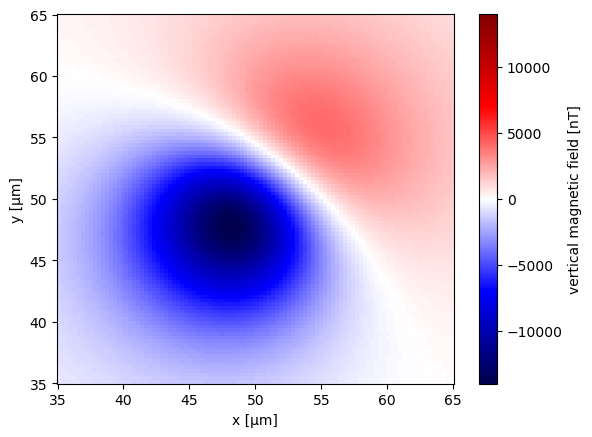

In [6]:
spacing = 0.3
data, dipole_coordinates, dipole_moments = simple_model(region, spacing, rng)
dx, dy, dz, tga = mg.gradient(data)

dataset = data.to_dataset()
dataset["dx"] = dx
dataset["dy"] = dy
dataset["dz"] = dz

dataset = dataset.sel(x=slice(35, 65), y=slice(35, 65))
dataset.bz.plot.pcolormesh(cmap="seismic")
table = vd.grid_to_table(dataset)

euler = hm.EulerDeconvolution(3)
euler.fit((table.x, table.y, table.z), (table.bz, table.dx, table.dy, table.dz))

print(euler.location_)
print(euler.base_level_)
print(table.bz.size)
plt.savefig("../assets/simple-model-2.png")

/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


[49.48501316 50.03671548 -3.0146029 ]
380.19355340521963
225


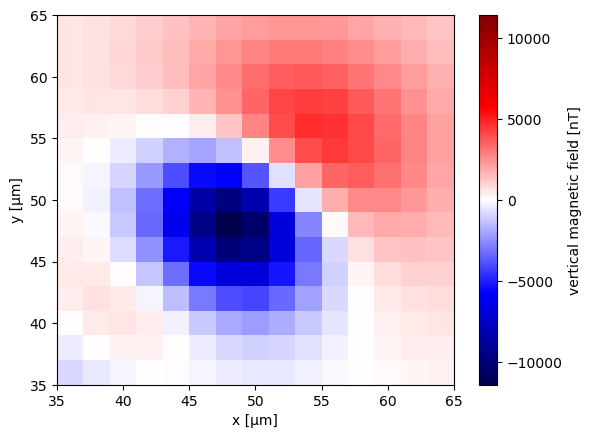

In [7]:
spacing = 2
data, dipole_coordinates, dipole_moments = one_interf_model(region, spacing, rng)
dx, dy, dz, tga = mg.gradient(data)

dataset = data.to_dataset()
dataset["dx"] = dx
dataset["dy"] = dy
dataset["dz"] = dz

dataset = dataset.sel(x=slice(35, 65), y=slice(35, 65))
dataset.bz.plot.pcolormesh(cmap="seismic")
table = vd.grid_to_table(dataset)

euler = hm.EulerDeconvolution(3)
euler.fit((table.x, table.y, table.z), (table.bz, table.dx, table.dy, table.dz))

print(euler.location_)
print(euler.base_level_)
print(table.bz.size)
plt.savefig("../assets/one-interf.png")

/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


[49.46172689 49.99550372 -3.28233359]
346.9759570236077
961


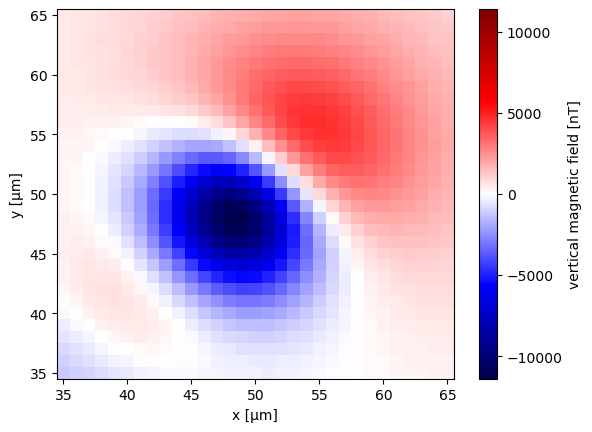

In [8]:
spacing = 1
data, dipole_coordinates, dipole_moments = one_interf_model(region, spacing, rng)
dx, dy, dz, tga = mg.gradient(data)

dataset = data.to_dataset()
dataset["dx"] = dx
dataset["dy"] = dy
dataset["dz"] = dz

dataset = dataset.sel(x=slice(35, 65), y=slice(35, 65))
dataset.bz.plot.pcolormesh(cmap="seismic")
table = vd.grid_to_table(dataset)

euler = hm.EulerDeconvolution(3)
euler.fit((table.x, table.y, table.z), (table.bz, table.dx, table.dy, table.dz))

print(euler.location_)
print(euler.base_level_)
print(table.bz.size)
plt.savefig("../assets/one-interf-1.png")

In [11]:
SEED = 5
rng = np.random.default_rng(SEED)
region = [30, 70, 30, 70]

spacing = 0.3
data, dipole_coordinates, dipole_moments = one_interf_model(region, spacing, rng)
data

<xarray.DataArray 'bz' (y: 134, x: 134)> Size: 144kB
array([[-1324.57845382, -1347.72294652, -1354.00084735, ...,
          134.19356857,   139.85055403,   135.59900768],
       [-1325.17130177, -1329.81176948, -1358.95317514, ...,
          142.95971357,   148.82835161,   128.99043267],
       [-1360.05520155, -1348.49776166, -1377.37989883, ...,
          133.10506917,   159.69964479,   139.42906624],
       ...,
       [  222.70837528,   244.06457705,   244.47020587, ...,
          521.49372483,   499.62401492,   491.90317503],
       [  216.968395  ,   215.63043008,   240.79947359, ...,
          520.1120227 ,   513.73114845,   493.37820838],
       [  203.59484482,   227.26570422,   229.51242941, ...,
          511.22078501,   496.12790063,   474.43690678]], shape=(134, 134))
Coordinates:
  * y        (y) float64 1kB 30.0 30.3 30.6 30.9 31.2 ... 69.1 69.4 69.7 70.0
  * x        (x) float64 1kB 30.0 30.3 30.6 30.9 31.2 ... 69.1 69.4 69.7 70.0
    z        (y, x) float64 144kB 5.0 5.0 5.0 5.0 5.0 ... 5.0 5.0 5.0 5.0 5.0
Attributes:
    long_name:  vertical magnetic field
    units:      nT

/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/home/yagomcastro/miniforge3/envs/magali-paper/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


[49.47668217 49.9977777  -2.24548335]
390.6767343148342
10000


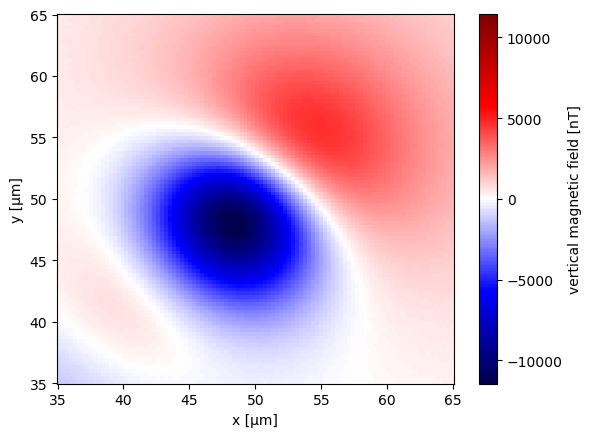

In [9]:
spacing = 0.3
data, dipole_coordinates, dipole_moments = one_interf_model(region, spacing, rng)
dx, dy, dz, tga = mg.gradient(data)

dataset = data.to_dataset()
dataset["dx"] = dx
dataset["dy"] = dy
dataset["dz"] = dz

dataset = dataset.sel(x=slice(35, 65), y=slice(35, 65))
dataset.bz.plot.pcolormesh(cmap="seismic")
table = vd.grid_to_table(dataset)

euler = hm.EulerDeconvolution(3)
euler.fit((table.x, table.y, table.z), (table.bz, table.dx, table.dy, table.dz))

print(euler.location_)
print(euler.base_level_)
print(table.bz.size)
plt.savefig("../assets/one-interf-2.png")